In [1]:
%matplotlib inline
from collections import Counter, deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
from scipy import stats
from tqdm.notebook import tqdm

/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
HEADLINES_PATH = Path('../../data/headlines/rent_rents.csv')
ASKING_ROOT    = Path('../../data/statscan-quarterly-rental-clean/can-cma-all')
CODING_ROOT    = Path('headline_coding')   # pre-computed classification/validation artifacts

# ── Rule-based relevance filter (Section 2): cheap, deterministic exclusions ──
COMMERCIAL = ['commercial rent', 'retail rent', 'office rent', 'industrial rent', 'franchise',
              'commercial landlord', 'commercial tenant', 'office space', 'retail space',
              'industrial space', 'mall rent', 'strip mall', 'warehouse rent', 'commercial lease',
              'retail lease', 'office lease']
POLICY_ONLY = ['rent control', 'rent cap', 'allowable rent increase', 'guideline increase',
               'rent increase guideline', 'rent freeze', 'above-guideline', 'rent bank',
               'rent assist', 'rent subsidy', 'rent relief', 'rent deferral',
               'rent-geared-to-income', 'rent-geared to income', 'affordable housing benefit']

# ── Near-duplicate/wire-story clustering (Section 4) ──────────────────
DEDUP_STOPWORDS = {'the', 'a', 'an', 'to', 'in', 'of', 'for', 'on', 'and', 'is', 'are', 'as',
                    'with', 'at', 'by', 'from', 'after', 'over', 'amid', 'than', 'it', 'its',
                    'this', 'that'}
DEDUP_WINDOW_DAYS = np.timedelta64(3, 'D')  # candidate wire-story pairs must publish within 3 days
DEDUP_JACCARD_MIN = 0.5                      # word-set overlap threshold to call two titles "the same story"

# ── Geography: map free-text location entities (from LLM classification) to
# this repo's CMA file names, so local headlines can be checked against that
# city's own asking-rent series instead of only the national one. Only
# includes aliases for places covered by this repo's 42-CMA asking-rent
# dataset; everything else is left unmatched (documented in Section 7).
LOCATION_TO_CMA = {
    'toronto': 'toronto', 'gta': 'toronto', 'greater toronto area': 'toronto',
    'north york': 'toronto', 'leslieville': 'toronto', 'parkdale': 'toronto',
    'east york': 'toronto', 'brampton': 'toronto', 'mississauga': 'toronto',
    'vancouver': 'vancouver', 'metro vancouver': 'vancouver', 'east vancouver': 'vancouver',
    'richmond': 'vancouver', 'new westminster': 'vancouver', 'port moody': 'vancouver',
    'coquitlam': 'vancouver', 'surrey': 'vancouver',
    'montreal': 'montreal', 'park extension': 'montreal', 'park-extension': 'montreal',
    'mile end': 'montreal', 'saint-michel': 'montreal',
    'hamilton': 'hamilton', 'mount hope': 'hamilton', 'burlington': 'hamilton',
    'kelowna': 'kelowna', 'west kelowna': 'kelowna', 'westbank first nation': 'kelowna',
    'red deer': 'red deer',
    'calgary': 'calgary',
    'ottawa': 'ottawa', 'centrepointe': 'ottawa',
    'windsor': 'windsor',
    'winnipeg': 'winnipeg',
    'saskatoon': 'saskatoon',
    'halifax': 'halifax',
    'london': 'london',
    'regina': 'regina',
    'victoria': 'victoria', 'greater victoria': 'victoria', 'saanich': 'victoria',
    'niagara': 'st. catharines-niagara', 'st. catharines': 'st. catharines-niagara',
    'niagara falls': 'st. catharines-niagara',
    'edmonton': 'edmonton', 'nisku': 'edmonton',
    'lethbridge': 'lethbridge',
    'kingston': 'kingston',
    'sudbury': 'greater sudbury',
    'kitchener': 'kitchener-cambridge-waterloo', 'cambridge': 'kitchener-cambridge-waterloo',
    'waterloo': 'kitchener-cambridge-waterloo', 'waterloo region': 'kitchener-cambridge-waterloo',
    'guelph': 'guelph',
    'nanaimo': 'nanaimo',
    'abbotsford': 'abbotsford-mission',
    'chilliwack': 'chilliwack',
    'moncton': 'moncton',
    'saint john': 'saint john',
    'sherbrooke': 'sherbrooke',
    'fredericton': 'fredericton',
    'quebec city': 'quebec',
    'barrie': 'barrie',
    'peterborough': 'peterborough',
    'thunder bay': 'thunder bay',
    'oshawa': 'oshawa',
    'belleville': 'belleville-quinte west', 'quinte': 'belleville-quinte west',
    'brantford': 'brantford',
    'drummondville': 'drummondville',
    'saguenay': 'saguenay',
    'trois-rivieres': 'trois-rivieres',
    'gatineau': 'gatineau',
}


def match_cma(location_entity):
    """Best-effort match of a free-text location string to a CMA file key."""
    if not isinstance(location_entity, str):
        return None
    text = location_entity.lower()
    for alias, cma in sorted(LOCATION_TO_CMA.items(), key=lambda kv: -len(kv[0])):
        if alias in text:
            return cma
    return None


def parse_quarter(qstr):
    qtr, year = qstr.split()
    return pd.Period(f'{year}{qtr}', freq='Q')


# ── Chart style (reference palette, consistent with other notebooks) ───
C1 = '#2a78d6'  # blue   — rising
C2 = '#008300'  # green  — falling
C3 = '#eda100'  # yellow — mixed/other
C4 = '#4a3aa7'  # violet — secondary comparator
C5 = '#e34948'  # red    — actual rent series
C6 = '#1baf7a'  # aqua   — spare

SURFACE  = '#fcfcfb'
INK      = '#0b0b0b'
INK2     = '#52514e'
MUTED    = '#898781'
GRID_CLR = '#e1e0d9'

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.edgecolor':    GRID_CLR,
    'axes.labelcolor':   INK2,
    'xtick.color':       INK2,
    'ytick.color':       INK2,
    'grid.color':        GRID_CLR,
    'grid.linewidth':    0.5,
    'figure.facecolor':  SURFACE,
    'axes.facecolor':    SURFACE,
})

# Does rent-headline framing foreground the recent reversal more than its limited scale?

This is a revised, narrower follow-up to the first pass at
[`explore_rent_headlines.ipynb`](explore_rent_headlines.ipynb) (superseded by
this notebook) and to [`explore_falling_rents.ipynb`](explore_falling_rents.ipynb),
which established the underlying reality: national 2BR asking rents rose
about **48%** from 2019 to a 2023 Q4 peak, then corrected only about
**4-9%** back down — real, but modest next to the run-up.

**The question here:**

> Does Canadian news coverage foreground the recent change in the direction
> of rents more strongly than the limited scale of the decline relative to
> the preceding increase?

This is **not** an attempt to prove media bias. It's an exploratory look at
headline emphasis and contextualization — volume, timing, and whether
falling-rent headlines tell readers how the fall compares to the run-up
that preceded it. A reversal after years of increases is inherently
newsworthy; disproportionate attention doesn't, by itself, mean inaccurate
or biased reporting. Section 10 returns to that distinction explicitly.

**What changed from the first pass, and why:**

- **Filtering.** The old notebook's only exclusion was "rent used as a verb."
  This version adds rule-based exclusions for commercial/franchise rent,
  rent-control/policy-only announcements, and obvious multi-topic digest
  headlines — and then, critically, layers a *semantic* pass on top, because
  the rule-based filter turns out to still let a lot of irrelevant content
  through (Section 3).
- **Classification.** The old notebook inferred direction from keyword
  proximity in a dependency tree. This version uses real semantic
  classification — because there's no LLM API available inside this
  execution environment (no `anthropic`/`openai` package, no key, no `claude`
  CLI), that classification was done by Claude itself, run as batched
  sub-agents over a stratified random sample of headlines, each returning a
  label, a geography tag, and a one-line rationale. All of that is then
  **manually validated** (Section 3) — every falling and mixed headline,
  plus random samples of rising and no-direction/irrelevant headlines — with
  agreement rates reported.
- **Deduplication.** Beyond exact-title matches, near-duplicate/syndicated
  wire stories are now clustered by word overlap and publish-date proximity
  (Section 4), so raw headline counts and deduplicated story counts are both
  reported.
- **Geography.** Headlines are tagged national/provincial/metro-local/
  multiple, and local headlines are checked against their own city's
  asking-rent series where this repo's data covers that city (Section 7).
- **Contextualization.** The old keyword-based proxy is replaced with direct
  coding of every falling-rent headline in the sample against a specific
  rubric — magnitude, historical, peak, affordability, level, and
  contrasting-geography context (Section 8).

Because the classification and manual-validation steps require an LLM/human
in the loop that can't run live inside `nbconvert`, they were run once,
outside this notebook, and the results cached to CSVs under
`headline_coding/`. Everything reproducible without that step — the rule-based
filter, deduplication, quarterly aggregation, geography matching, statistics,
and charts — runs live in the cells below. Section 3 documents the offline
methodology in full, including error rates, so this is auditable rather than
a black box.

## Section 1 — Load headlines and apply a first-pass relevance filter

`data/headlines/rent_rents.csv` is untouched from the original collection —
every English/French Canadian-media headline containing "rent" or "rents,"
2019 Q1 through 2026 Q1. This section applies a cheap, fully deterministic
rule-based filter before any semantic classification:

- drop non-English headlines and exact-duplicate titles (syndication);
- drop **commercial/franchise/retail/office/industrial** rent headlines;
- drop **rent-control or allowable-increase policy** headlines that describe
  a regulatory ceiling, not an observed market rent;
- drop obvious **multi-topic digest/roundup** headlines (local-paper "Today
  in ___" columns joining unrelated stories with " + ");
- drop headlines where "rent" only appears as a **verb** ("rent a cottage"),
  via spaCy part-of-speech tagging.

This is the same kind of filter the first-pass notebook used — and, as
Section 3 shows, it is not sufficient on its own. It's a first-pass filter,
not a relevance classifier.

In [3]:
nlp = spacy.load('en_core_web_sm', disable=['ner'])

raw = pd.read_csv(HEADLINES_PATH, parse_dates=['publish_date'])
print(f'{len(raw):,} rows loaded, {raw["publish_date"].min().date()} to {raw["publish_date"].max().date()}')

en = raw[raw['language'] == 'en'].copy()
en['title_norm'] = en['title'].str.strip().str.lower()
en = en.drop_duplicates(subset='title_norm').reset_index(drop=True)
en['quarter'] = en['publish_date'].dt.to_period('Q')
en['row_id'] = ['H%05d' % i for i in range(len(en))]
print(f'{len(raw) - len(en):,} non-English / duplicate-title rows dropped -> {len(en):,} unique English headlines')

4,989 rows loaded, 2019-01-03 to 2026-03-27
1,603 non-English / duplicate-title rows dropped -> 3,386 unique English headlines


In [4]:
en['is_commercial']  = en['title_norm'].str.contains('|'.join(COMMERCIAL), regex=True)
en['is_policy_only'] = en['title_norm'].str.contains('|'.join(POLICY_ONLY), regex=True)
en['is_roundup']     = en['title'].str.contains(' + ', regex=False)

docs = list(tqdm(nlp.pipe(en['title'].tolist(), batch_size=64), total=len(en), desc='Tagging parts of speech'))
en['has_rent_noun'] = [any(t.lemma_.lower() == 'rent' and t.pos_ in ('NOUN', 'PROPN') for t in d) for d in docs]

excluded = en['is_commercial'] | en['is_policy_only'] | en['is_roundup'] | ~en['has_rent_noun']
en['exclusion_reason'] = np.select(
    [en['is_commercial'], en['is_policy_only'], en['is_roundup'], ~en['has_rent_noun']],
    ['commercial', 'policy_only', 'roundup_digest', 'rent_as_verb'],
    default='none',
)
print(en['exclusion_reason'].value_counts())

candidates = en[~excluded].copy().reset_index(drop=True)
print(f'\nResidential-rent candidates after rule-based filtering: {len(candidates):,} of {len(en):,}')

Tagging parts of speech:   0%|          | 0/3386 [00:00<?, ?it/s]

exclusion_reason
none              2298
policy_only        535
rent_as_verb       459
commercial          77
roundup_digest      17
Name: count, dtype: int64

Residential-rent candidates after rule-based filtering: 2,298 of 3,386


## Section 2 — Stratified sample for semantic classification

Running full LLM-quality semantic classification (with a rationale per
headline) on all ~2,300 candidates would require dozens of batched
sub-agent calls. Following standard media-content-analysis practice, a
large **quarter-stratified random sample** was drawn instead — large enough
to support valid quarterly trend estimates, small enough to classify with a
real rationale per item and manually validate a meaningful share of it. Each
quarter contributes at least 25 headlines (or all of them, if a quarter has
fewer) and otherwise 40% of that quarter's candidates, so busy quarters
aren't over-weighted and quiet quarters aren't invisible.

In [5]:
rng = np.random.default_rng(20260723)
SAMPLE_FRAC, MIN_PER_QUARTER = 0.40, 25

sample_ids = []
for qtr, grp in candidates.groupby('quarter'):
    k = min(len(grp), max(MIN_PER_QUARTER, round(SAMPLE_FRAC * len(grp))))
    sample_ids.extend(rng.choice(grp['row_id'].values, size=k, replace=False).tolist())

candidates['in_sample'] = candidates['row_id'].isin(sample_ids)
print(f'Sample: {candidates["in_sample"].sum():,} of {len(candidates):,} candidates '
      f'({candidates["in_sample"].mean():.1%})')

Sample: 965 of 2,298 candidates (42.0%)


## Section 3 — Semantic classification and manual validation

**Methodology.** Each of the 965 sampled headlines was classified by Claude
(run as batched sub-agents, ~50 headlines per batch, each returning
structured JSON) into exactly one of seven categories, plus a geography tag
and a one-sentence rationale:

| Direction | Meaning |
|---|---|
| `rising` | Reports/implies residential rents going up |
| `falling` | Reports/implies residential rents going down |
| `mixed_divergent` | Rents rising in one place/segment, falling in another, in the same headline |
| `stable_unchanged` | Rents holding steady |
| `no_clear_direction` | Genuinely about rent prices/affordability, no direction stated |
| `forecast` | A *prediction* about future rent direction, not an observed change |
| `irrelevant_non_residential` | Not actually about residential market rent levels, despite passing Section 1's filter |

**Manual validation.** Every `falling` and `mixed_divergent` headline (86),
plus a random sample of 55 `rising` and 55 `no_clear_direction`/
`irrelevant_non_residential` headlines (196 headlines total, more than 20%
of the sample) were then read and re-judged directly — a second,
independent pass distinct from the classification itself — with any
disagreement corrected. The four corrections that came out of that pass:

- Two headlines were pulled *out of* `mixed_divergent` because they didn't
  actually describe two different observed directions (one was a
  policy/loophole story, one was a comparative-level-plus-vague-forecast
  story) — both moved to `no_clear_direction`.
- One headline moved *into* `falling` from `mixed_divergent` — it was a
  single national falling trend with strong historical context ("still way
  higher than 3 years ago"), not geographic divergence.
- One multi-topic digest headline that had slipped past the Section 1
  roundup filter (comma-joined instead of "+"-joined) was reclassified from
  `rising` to `irrelevant_non_residential`.

Manually corrected labels are used as the final labels everywhere below.

In [6]:
sample = candidates.merge(
    pd.read_csv(CODING_ROOT / 'sample_final.csv')[
        ['row_id', 'direction', 'geography', 'location_entity', 'rationale',
         'manual_reviewed', 'llm_direction', 'final_direction', 'correction_note']
    ],
    on='row_id', how='left',
)
assert (sample.loc[sample['in_sample'], 'final_direction'].notna()).all(), 'every sampled row must have a label'

classified = sample[sample['in_sample']].copy()
n_reviewed  = classified['manual_reviewed'].sum()
n_corrected = (classified['llm_direction'] != classified['final_direction']).sum()
print(f'Classified sample: {len(classified):,}')
print(f'Manually reviewed: {n_reviewed:,} ({n_reviewed / len(classified):.1%} of the sample)')
print(f'Corrected on review: {n_corrected} '
      f'(agreement rate on the reviewed subset: {(n_reviewed - n_corrected) / n_reviewed:.1%})')
print()
print(classified['final_direction'].value_counts())

Classified sample: 965
Manually reviewed: 196 (20.3% of the sample)
Corrected on review: 4 (agreement rate on the reviewed subset: 98.0%)

final_direction
irrelevant_non_residential    522
rising                        201
no_clear_direction            116
falling                        77
forecast                       28
stable_unchanged               14
mixed_divergent                 7
Name: count, dtype: int64


In [7]:
corrections = classified[classified['llm_direction'] != classified['final_direction']]
print('The corrections themselves:')
for _, r in corrections.iterrows():
    print(f"  {r['row_id']}: {r['llm_direction']} -> {r['final_direction']}")
    print(f"    \"{r['title']}\"")
    print(f"    {r['correction_note']}")

The corrections themselves:
  H00007: mixed_divergent -> no_clear_direction
    "Rent discounts create 'back door' for future hikes, says Manitoba tenant calling for rule changes"
    Manual review: policy/loophole story about a discount practice, not an observed price divergence — does not fit "mixed" (geographic divergence).
  H00307: mixed_divergent -> no_clear_direction
    "London's apartment rents lower than most major cities, but pressure is building"
    Manual review: comparative rent level + vague forward-looking pressure, not an observed rise-in-one-place/fall-in-another.
  H00340: rising -> irrelevant_non_residential
    "WYWS: Rent shock, resto bonanza, jazz satellite discovery, and holiday-labour negotiating"
    Manual review: multi-topic roundup/digest column (comma-joined unrelated items) that slipped past the " + " roundup filter; rent mention is incidental with no stated direction.
  H00840: mixed_divergent -> falling
    "Annual rents just hit a 15-month low — but t

In [8]:
n_irrelevant = (classified['final_direction'] == 'irrelevant_non_residential').mean()
print(f'{n_irrelevant:.1%} of headlines that passed the Section 1 rule-based relevance filter '
      f'were still judged irrelevant to residential market rent trends on semantic review '
      f'(rent-relief programs, individual landlord-tenant disputes, "rent-a-X" services, '
      f'human-interest mentions, etc. that slipped through keyword matching). '
      f'This is the clearest evidence that keyword/rule-based filtering alone is not a reliable '
      f'way to build this kind of sample -- semantic classification changes the denominator '
      f'substantially, not just the direction labels.')

54.1% of headlines that passed the Section 1 rule-based relevance filter were still judged irrelevant to residential market rent trends on semantic review (rent-relief programs, individual landlord-tenant disputes, "rent-a-X" services, human-interest mentions, etc. that slipped through keyword matching). This is the clearest evidence that keyword/rule-based filtering alone is not a reliable way to build this kind of sample -- semantic classification changes the denominator substantially, not just the direction labels.


## Section 4 — Beyond exact duplicates: clustering syndicated coverage

Section 1 already dropped exact-duplicate titles. But Canadian local-news
chains (Metroland, Village Media, Postmedia, etc.) frequently republish the
same wire story with a slightly reworded headline — same event, same day,
different outlet. Counting those separately would measure how many papers a
chain owns, not how many distinct stories got covered.

Two headlines are clustered as **the same coverage event** if they publish
within 3 days of each other AND share at least half their (stopword-stripped)
words by Jaccard similarity. This is a lightweight, fully transparent
alternative to matching on wire-service bylines (not available in this
dataset) or exact text (already used in Section 1). Every candidate headline
gets both a raw count and a cluster ("story") ID; the rest of the notebook
reports **both** where it matters.

In [9]:
def tokenize(title):
    words = pd.Series(title.lower()).str.findall(r"[a-z0-9']+").iloc[0]
    return set(w for w in words if w not in DEDUP_STOPWORDS and len(w) > 1)

candidates = candidates.sort_values('publish_date').reset_index(drop=True)
candidates['tokens'] = candidates['title'].map(tokenize)

n = len(candidates)
parent = list(range(n))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

dates, tokens = candidates['publish_date'].values, candidates['tokens'].tolist()
for i in tqdm(range(n), desc='Clustering near-duplicates'):
    for j in range(i + 1, n):
        if dates[j] - dates[i] > DEDUP_WINDOW_DAYS:
            break
        ti, tj = tokens[i], tokens[j]
        if not ti or not tj:
            continue
        jac = len(ti & tj) / len(ti | tj)
        if jac >= DEDUP_JACCARD_MIN:
            union(i, j)

candidates['story_cluster'] = [find(i) for i in range(n)]
n_stories = candidates['story_cluster'].nunique()
print(f'{n:,} raw candidate headlines -> {n_stories:,} deduplicated coverage events '
      f'({n - n_stories:,} further collapsed as syndicated/wire duplicates, '
      f'{(n - n_stories) / n:.1%} of the total)')

Clustering near-duplicates:   0%|          | 0/2298 [00:00<?, ?it/s]

2,298 raw candidate headlines -> 2,111 deduplicated coverage events (187 further collapsed as syndicated/wire duplicates, 8.1% of the total)


In [10]:
cluster_sizes = candidates.groupby('story_cluster').size().sort_values(ascending=False)
print('Largest syndicated-coverage clusters:')
for cl, sz in cluster_sizes.head(3).items():
    if sz < 3:
        break
    print(f'\n--- {sz} outlets, same story ---')
    sub = candidates[candidates['story_cluster'] == cl][['publish_date', 'media_name', 'title']]
    for _, r in sub.iterrows():
        print(f"  {r['publish_date'].date()} [{r['media_name']}] {r['title']}")

Largest syndicated-coverage clusters:

--- 5 outlets, same story ---
  2024-12-23 [pentictonherald.ca] The rent-a-friend industry is booming among Canada's Chinese diaspora
  2024-12-23 [ctvnews.ca] Rent-a-friend industry booms among Chinese diaspora
  2024-12-23 [ctvnews.ca] Rent-a-friend industry Xiaohongshu booming among Canada's Chinese diaspora
  2024-12-23 [thestar.com] The rent-a-friend industry is booming among Canada’s Chinese diaspora
  2024-12-23 [kimberleybulletin.com] Rent-a-friend business booms as B.C.’s Chinese diaspora copes with isolation

--- 4 outlets, same story ---
  2024-08-15 [pentictonherald.ca] Tenant advocate decries 'troubling' ruling that let landlord hike rent by 27 per cent
  2024-08-15 [theglobeandmail.com] Tenant advocate decries ‘troubling’ ruling that let landlord hike rent by 27 per cent
  2024-08-15 [kelownadailycourier.ca] Tenant advocate decries ruling that let B.C. landlord hike rent 27% after rates rose
  2024-08-16 [ctvnews.ca] Concerns over ru

In [11]:
sample = sample.merge(candidates[['row_id', 'story_cluster']], on='row_id', how='left')
classified = sample[sample['in_sample']].copy()

## Section 5 — Overall directional balance

Restricting to the classified sample's clearly-directional headlines
(`rising`, `falling`, `mixed_divergent` — dropping `stable_unchanged`,
`no_clear_direction`, `forecast`, and `irrelevant_non_residential`, none of
which describe an observed rise or fall to compare).

285 directional headlines in the classified sample: 201 rising, 77 falling, 7 mixed/geographically divergent
Rising vs. falling only: 201 (72.3%) vs. 77 (27.7%)


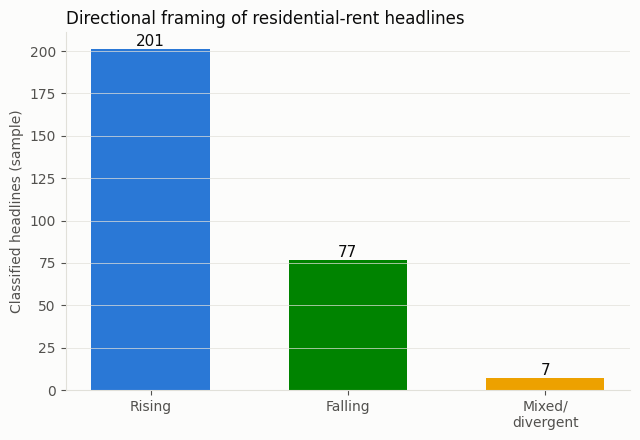

In [12]:
directional = classified[classified['final_direction'].isin(['rising', 'falling', 'mixed_divergent'])].copy()
counts = directional['final_direction'].value_counts()
n_rising, n_falling, n_mixed = counts.get('rising', 0), counts.get('falling', 0), counts.get('mixed_divergent', 0)
n_dir = n_rising + n_falling

print(f'{len(directional):,} directional headlines in the classified sample: '
      f'{n_rising} rising, {n_falling} falling, {n_mixed} mixed/geographically divergent')
print(f'Rising vs. falling only: {n_rising} ({n_rising/n_dir:.1%}) vs. {n_falling} ({n_falling/n_dir:.1%})')

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(['Rising', 'Falling', 'Mixed/\ndivergent'], [n_rising, n_falling, n_mixed],
              color=[C1, C2, C3], width=0.6)
for b in bars:
    ax.annotate(f'{int(b.get_height())}', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', color=INK, fontsize=11)
ax.set_ylabel('Classified headlines (sample)')
ax.set_title('Directional framing of residential-rent headlines', color=INK, loc='left')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

## Section 6 — Matching coverage to the actual rent trend, by quarter

For every quarter: rising/falling headline counts (raw and deduplicated by
story cluster), the falling share of directional headlines, the actual
national quarter-over-quarter asking-rent change, and its magnitude. The
sample is a 40%-ish stratified draw, not a census, so quarterly counts here
are **sample counts** — treated as indicative of relative volume and timing,
not as precise population totals.

In [13]:
asking_national = pd.read_csv(ASKING_ROOT / 'all.csv')
asking_national['quarter'] = asking_national['Quarter'].map(parse_quarter)
asking_national = asking_national.set_index('quarter')['Apt 2br'].sort_index()
qoq_pct = asking_national.pct_change() * 100

directional['is_rising']  = directional['final_direction'] == 'rising'
directional['is_falling'] = directional['final_direction'] == 'falling'

q = directional.groupby('quarter').agg(
    n_rising=('is_rising', 'sum'),
    n_falling=('is_falling', 'sum'),
).sort_index()
q['n_total'] = q['n_rising'] + q['n_falling']

dedup_dir = directional.drop_duplicates(subset='story_cluster')
q_dedup = dedup_dir.groupby('quarter').agg(
    n_rising_dedup=('is_rising', 'sum'),
    n_falling_dedup=('is_falling', 'sum'),
).sort_index()
q = q.join(q_dedup)

q['share_falling'] = q['n_falling'] / q['n_total']
q['qoq_pct'] = qoq_pct
q['qoq_abs'] = q['qoq_pct'].abs()
print(q.round(3))

         n_rising  n_falling  n_total  n_rising_dedup  n_falling_dedup  \
quarter                                                                  
2019Q1          2          0        2               2                0   
2019Q2          7          0        7               7                0   
2019Q3          6          0        6               6                0   
2019Q4          4          0        4               4                0   
2020Q1         10          0       10              10                0   
2020Q2          1          3        4               1                3   
2020Q3          2          2        4               2                2   
2020Q4          3          6        9               3                6   
2021Q1          3          2        5               3                2   
2021Q2          4          2        6               4                2   
2021Q3          6          1        7               6                1   
2021Q4          1          0        1 

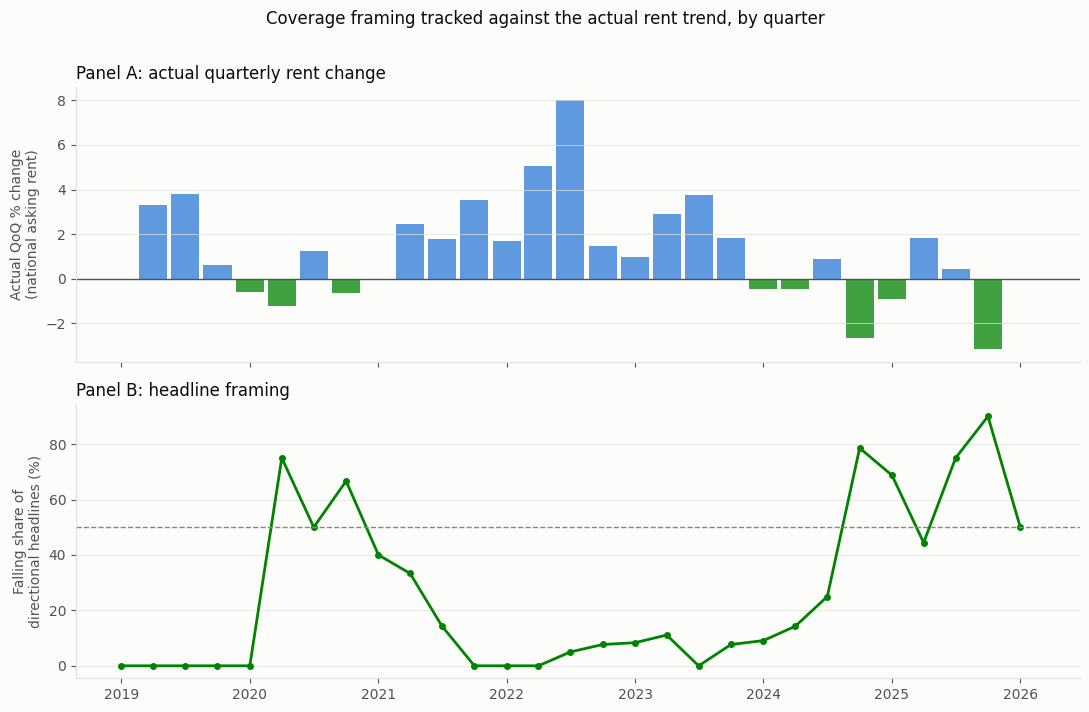

In [14]:
# Chart 1: quarterly national rent change and falling-share, aligned panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                 gridspec_kw={'height_ratios': [1, 1]})

qx = q.index.to_timestamp()
ax1.bar(qx, q['qoq_pct'], width=80, color=[C2 if v < 0 else C1 for v in q['qoq_pct']], alpha=0.75)
ax1.axhline(0, color=INK2, lw=1)
ax1.set_ylabel('Actual QoQ % change\n(national asking rent)')
ax1.set_title('Panel A: actual quarterly rent change', color=INK, loc='left')
ax1.grid(axis='y')

ax2.plot(qx, q['share_falling']*100, color=C2, lw=2, marker='o', ms=4)
ax2.axhline(50, color=MUTED, lw=1, ls='--')
ax2.set_ylabel('Falling share of\ndirectional headlines (%)')
ax2.set_title('Panel B: headline framing', color=INK, loc='left')
ax2.grid(axis='y')

fig.suptitle('Coverage framing tracked against the actual rent trend, by quarter', y=1.01, color=INK)
plt.tight_layout()
plt.show()

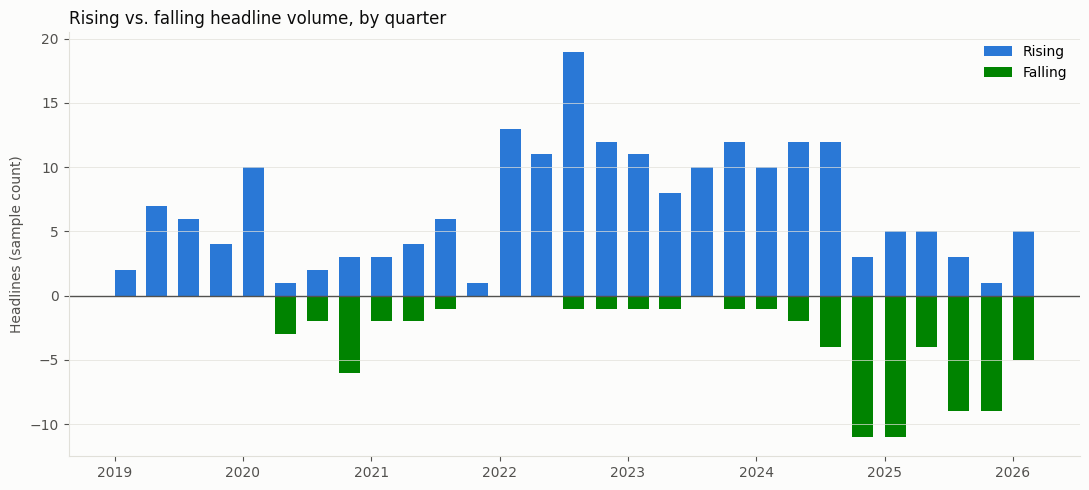

In [15]:
# Chart 2: rising vs falling headline counts by quarter
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(qx, q['n_rising'], width=60, color=C1, label='Rising', align='edge')
ax.bar(qx, -q['n_falling'], width=60, color=C2, label='Falling', align='edge')
ax.axhline(0, color=INK2, lw=1)
ax.set_ylabel('Headlines (sample count)')
ax.set_title('Rising vs. falling headline volume, by quarter', color=INK, loc='left')
ax.legend(frameon=False)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

### Headlines per quarter of a given direction, and per point of magnitude

Two purely descriptive benchmarks, **not** framed as formal null hypotheses:
how many headlines show up, on average, for a quarter where rent was rising
vs. one where it was falling; and how many headlines show up per percentage
point of absolute quarterly change, in each direction.

In [16]:
rising_quarters  = q[q['qoq_pct'] > 0]
falling_quarters = q[q['qoq_pct'] < 0]

headlines_per_rising_qtr  = rising_quarters['n_rising'].sum()  / len(rising_quarters)
headlines_per_falling_qtr = falling_quarters['n_falling'].sum() / len(falling_quarters)
print(f'Average rising headlines per rising-rent quarter:  {headlines_per_rising_qtr:.2f} '
      f'(over {len(rising_quarters)} quarters)')
print(f'Average falling headlines per falling-rent quarter: {headlines_per_falling_qtr:.2f} '
      f'(over {len(falling_quarters)} quarters)')

per_point_rising  = rising_quarters['n_rising'].sum()  / rising_quarters['qoq_abs'].sum()
per_point_falling = falling_quarters['n_falling'].sum() / falling_quarters['qoq_abs'].sum()
print(f'\nRising headlines per percentage point of cumulative quarterly rise:  {per_point_rising:.2f}')
print(f'Falling headlines per percentage point of cumulative quarterly fall:  {per_point_falling:.2f}')
print(f'Ratio (falling per-point rate / rising per-point rate): {per_point_falling / per_point_rising:.2f}x')

Average rising headlines per rising-rent quarter:  8.11 (over 18 quarters)
Average falling headlines per falling-rent quarter: 5.38 (over 8 quarters)

Rising headlines per percentage point of cumulative quarterly rise:  3.19
Falling headlines per percentage point of cumulative quarterly fall:  4.27
Ratio (falling per-point rate / rising per-point rate): 1.34x


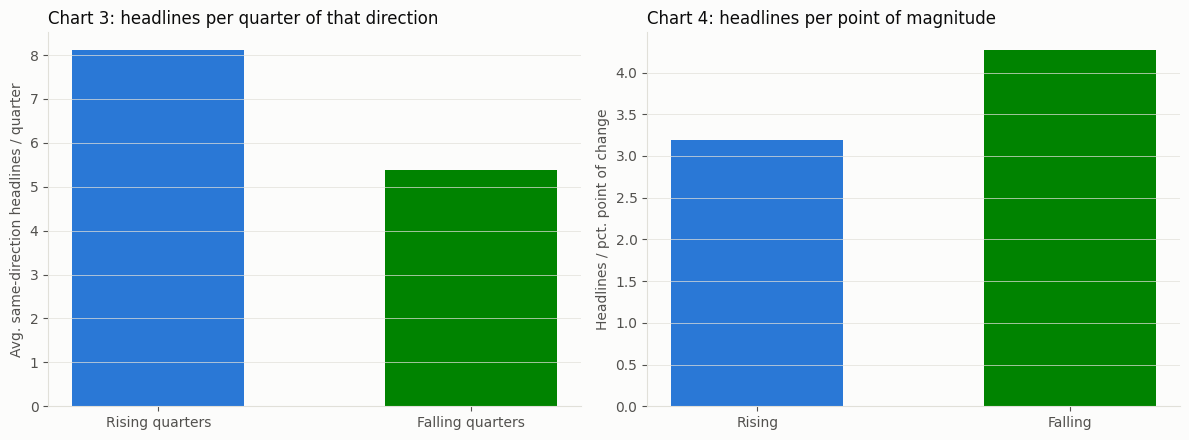

In [17]:
# Chart 3 & 4: headlines per quarter-of-that-direction, and per point of magnitude
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(['Rising quarters', 'Falling quarters'],
            [headlines_per_rising_qtr, headlines_per_falling_qtr], color=[C1, C2], width=0.55)
axes[0].set_ylabel('Avg. same-direction headlines / quarter')
axes[0].set_title('Chart 3: headlines per quarter of that direction', color=INK, loc='left')
axes[0].grid(axis='y')

axes[1].bar(['Rising', 'Falling'], [per_point_rising, per_point_falling], color=[C1, C2], width=0.55)
axes[1].set_ylabel('Headlines / pct. point of change')
axes[1].set_title('Chart 4: headlines per point of magnitude', color=INK, loc='left')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

### Before vs. after the national peak, and correlation checks

In [18]:
peak_idx = asking_national.idxmax()
before_peak = q[q.index <= peak_idx]
after_peak  = q[q.index >  peak_idx]

share_before = before_peak['n_falling'].sum() / before_peak['n_total'].sum()
share_after  = after_peak['n_falling'].sum()  / after_peak['n_total'].sum()
print(f'National asking-rent peak: {peak_idx}')
print(f'Falling-headline share of directional coverage BEFORE the peak: {share_before:.1%} '
      f'({int(before_peak["n_falling"].sum())}/{int(before_peak["n_total"].sum())})')
print(f'Falling-headline share of directional coverage AFTER the peak:  {share_after:.1%} '
      f'({int(after_peak["n_falling"].sum())}/{int(after_peak["n_total"].sum())})')

merged = q.dropna(subset=['qoq_pct']).copy()
merged['signal'] = merged['n_falling'] - merged['n_rising']
r_dir, p_dir = stats.pearsonr(merged['signal'], merged['qoq_pct'])
r_mag, p_mag = stats.spearmanr(merged['n_total'], merged['qoq_abs'])
print(f'\nCorrelation (headline signal vs. actual QoQ % change): r={r_dir:+.3f}, p={p_dir:.3g}')
print(f'Correlation (total directional headline VOLUME vs. magnitude of change): '
      f'rho={r_mag:+.3f}, p={p_mag:.3g}')
print('The first checks whether framing tracks the *direction* of the real trend; the second '
      'checks whether coverage volume tracks the *size* of the move, independent of direction.')

National asking-rent peak: 2023Q4
Falling-headline share of directional coverage BEFORE the peak: 12.7% (21/166)
Falling-headline share of directional coverage AFTER the peak:  50.0% (56/112)

Correlation (headline signal vs. actual QoQ % change): r=-0.653, p=0.000167
Correlation (total directional headline VOLUME vs. magnitude of change): rho=-0.059, p=0.765
The first checks whether framing tracks the *direction* of the real trend; the second checks whether coverage volume tracks the *size* of the move, independent of direction.


## Section 7 — National vs. local framing

Every classified headline also got a geography tag (`national`,
`provincial`, `metro_local`, `multiple`, `unclear`). For `metro_local`
headlines whose named city matches one of this repo's 42 CMAs, the
headline is checked against **that city's own** asking-rent series instead
of the national one — a Calgary headline about a Calgary rent drop should
be judged against what actually happened to Calgary rents, not the national
average. There's no provincial-level asking-rent aggregate in this repo's
data (mirroring the earlier finding that CMHC has no official Canada-wide
aggregate either), so `provincial` headlines are left out of the
local-match check.

In [19]:
print(classified['geography'].value_counts())

classified['matched_cma'] = classified['location_entity'].map(match_cma)
metro = classified[classified['geography'] == 'metro_local']
n_matched = metro['matched_cma'].notna().sum()
print(f'\nOf {len(metro)} metro/local headlines, {n_matched} ({n_matched/len(metro):.1%}) '
      f'named a city covered by this repo\'s asking-rent data and could be checked locally.')

geography
metro_local    338
unclear        311
provincial     159
national       135
multiple        22
Name: count, dtype: int64

Of 338 metro/local headlines, 288 (85.2%) named a city covered by this repo's asking-rent data and could be checked locally.


In [20]:
def local_check(row):
    if pd.isna(row['matched_cma']):
        return np.nan
    path = ASKING_ROOT / f"{row['matched_cma']}.csv"
    if not path.exists():
        return np.nan
    s = pd.read_csv(path)
    s['quarter'] = s['Quarter'].map(parse_quarter)
    s = s.set_index('quarter')['Apt 2br'].sort_index().dropna()
    if row['quarter'] not in s.index or s.index.get_loc(row['quarter']) == 0:
        return np.nan
    pos = s.index.get_loc(row['quarter'])
    return (s.iloc[pos] - s.iloc[pos - 1]) / s.iloc[pos - 1] * 100

metro = metro.copy()
metro['local_qoq_pct'] = metro.apply(local_check, axis=1)

local_dir = metro.dropna(subset=['local_qoq_pct'])
local_dir = local_dir[local_dir['final_direction'].isin(['rising', 'falling'])]
agrees = (
    ((local_dir['final_direction'] == 'rising')  & (local_dir['local_qoq_pct'] > 0)) |
    ((local_dir['final_direction'] == 'falling') & (local_dir['local_qoq_pct'] < 0))
)
print(f'{len(local_dir)} local-direction headlines could be checked against that city\'s own '
      f'quarterly asking-rent change.')
print(f'Headline direction matches the local quarterly change: {agrees.sum()}/{len(local_dir)} '
      f'({agrees.mean():.1%})')

123 local-direction headlines could be checked against that city's own quarterly asking-rent change.
Headline direction matches the local quarterly change: 80/123 (65.0%)


National-geography headlines: falling share = 49.2% (n=61)
Local/metro-geography headlines: falling share = 25.0% (n=132)


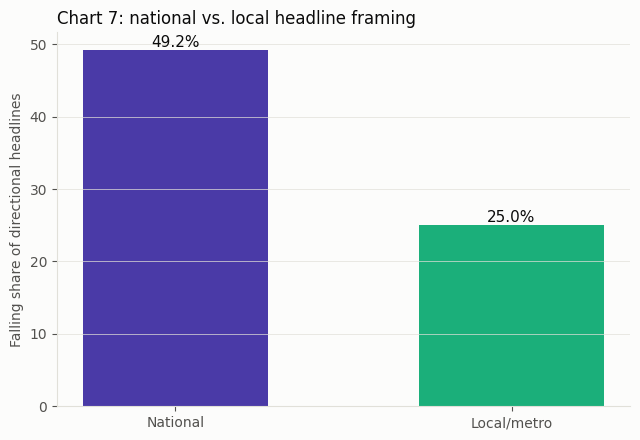

In [21]:
national_directional = directional[directional['geography'] == 'national']
local_directional    = directional[directional['geography'] == 'metro_local']

def falling_share(df):
    n = (df['final_direction'] == 'rising').sum() + (df['final_direction'] == 'falling').sum()
    if n == 0:
        return np.nan, 0
    return (df['final_direction'] == 'falling').sum() / n, n

nat_share, nat_n = falling_share(national_directional)
loc_share, loc_n = falling_share(local_directional)
print(f'National-geography headlines: falling share = {nat_share:.1%} (n={nat_n})')
print(f'Local/metro-geography headlines: falling share = {loc_share:.1%} (n={loc_n})')

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(['National', 'Local/metro'], [nat_share*100, loc_share*100], color=[C4, C6], width=0.55)
for b in bars:
    ax.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', color=INK, fontsize=11)
ax.set_ylabel('Falling share of directional headlines')
ax.set_title('Chart 7: national vs. local headline framing', color=INK, loc='left')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

## Section 8 — Does the falling-rent coverage explain how little has reversed?

The first-pass notebook used a keyword lexicon ("despite," "still," etc.) as
a proxy for contextualization — the user's own critique of that approach was
correct: generic hedge words don't confirm *what* they're qualifying. This
version directly reads and codes every one of the 77 final `falling`
headlines in the sample against a specific rubric, only tagging a category
when the headline explicitly makes that claim:

- **magnitude** — the decline is called slight/modest/marginal/limited;
- **historical** — rents are said to remain above 2019/pre-pandemic/another
  named earlier benchmark;
- **peak** — the decline is explicitly framed as only relative to a recent peak;
- **affordability** — rents are said to remain unaffordable/burdensome;
- **level** — rents are said to remain high, or among the highest in Canada;
- **contrasting geography** — falling here, explicitly rising elsewhere.

The **main outcome** is the share of falling-rent headlines that communicate
any of magnitude, level, historical, or peak context — i.e., that tell the
reader the decline is small, or that rents remain high, or that rents remain
well above an earlier benchmark. (Affordability context is coded and
reported, but isn't counted toward this specific outcome, since a headline
can say "rents remain unaffordable" without saying anything about how the
decline compares to the run-up.)

In [22]:
falling_coded = pd.read_csv(CODING_ROOT / 'falling_context_coded.csv')
CONTEXT_TAGS = ['magnitude_context', 'historical_context', 'peak_context',
                'affordability_context', 'level_context', 'contrasting_geography']

tag_counts = falling_coded[CONTEXT_TAGS].sum().sort_values(ascending=False)
print('Falling headlines carrying each context type (a headline can carry more than one):')
print(tag_counts)

n_any  = falling_coded['any_context'].sum()
n_core = falling_coded['core_outcome_context'].sum()
n_tot  = len(falling_coded)
print(f'\nAny meaningful context at all: {n_any}/{n_tot} ({n_any/n_tot:.1%})')
print(f'No meaningful context: {n_tot - n_any}/{n_tot} ({(n_tot-n_any)/n_tot:.1%})')
print(f'\nMAIN OUTCOME -- decline-is-small / remains-high / remains-above-benchmark '
      f'context (magnitude + level + historical + peak): {n_core}/{n_tot} ({n_core/n_tot:.1%})')

Falling headlines carrying each context type (a headline can carry more than one):
affordability_context    7
historical_context       6
magnitude_context        2
peak_context             1
level_context            1
contrasting_geography    0
dtype: int64

Any meaningful context at all: 17/77 (22.1%)
No meaningful context: 60/77 (77.9%)

MAIN OUTCOME -- decline-is-small / remains-high / remains-above-benchmark context (magnitude + level + historical + peak): 10/77 (13.0%)


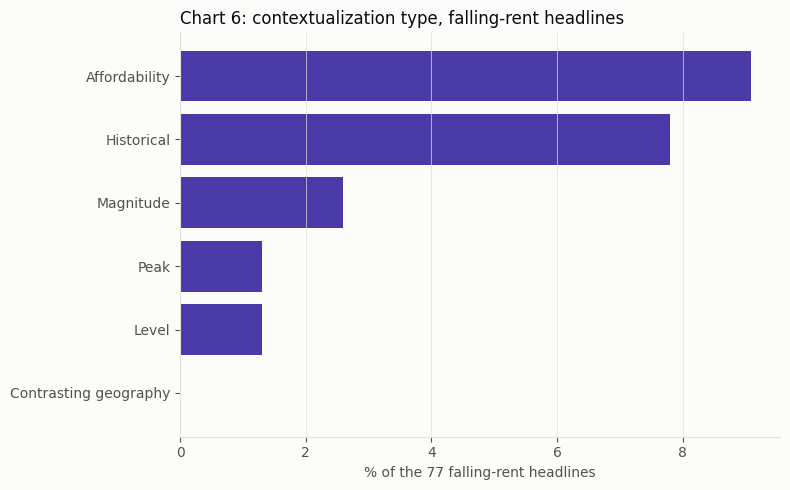

In [23]:
# Chart 6: share of falling headlines containing each context type
fig, ax = plt.subplots(figsize=(8, 5))
labels = [t.replace('_context', '').replace('_', ' ').capitalize() for t in tag_counts.index]
ax.barh(labels[::-1], (tag_counts / n_tot * 100)[::-1], color=C4)
ax.set_xlabel('% of the 77 falling-rent headlines')
ax.set_title('Chart 6: contextualization type, falling-rent headlines', color=INK, loc='left')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

In [24]:
print('Example FALLING headlines with NO meaningful context (the "bare decline" framing):')
bare = falling_coded[~falling_coded['any_context']]['title']
for s in bare.sample(min(8, len(bare)), random_state=3):
    print(' ', s)

print()
print('Example FALLING headlines WITH historical/peak context (the framing the hypothesis is looking for):')
ctx = falling_coded[(falling_coded['historical_context'] == 1) | (falling_coded['peak_context'] == 1)]['title']
for s in ctx:
    print(' ', s)

Example FALLING headlines with NO meaningful context (the "bare decline" framing):
  Study says short term rental rules lowered rent
  Vancouver rents drop as market softens in Canada's major metro areas
  Rents in Calgary's secondary market start the year with a dip
  Rents in Canada fall for 11th straight month. Which cities saw biggest drops?
  Ottawa Real Estate: Average rent drops in Ottawa in October
  Average asking rents decrease for fifth straight month to $2,088: report
  B.C. rent decline leads Canadian jurisdictions in December
  A GTA renters’ market? Here’s how fast rents are dropping in Mississauga, Brampton, Oakville, Oshawa and other Toronto area cities

Example FALLING headlines WITH historical/peak context (the framing the hypothesis is looking for):
  Rents in Canada fall for 9th straight month, still above 2022 levels
  Canadian rents, already dropping from peaks, could drop further from Trump’s tariffs
  Annual rents just hit a 15-month low — but they're still way

## Section 9 — How much does deduplication change the picture?

Comparing raw vs. deduplicated (story-cluster) counts for the classified
sample's rising and falling headlines, quarter by quarter.

In [25]:
raw_totals   = q[['n_rising', 'n_falling']].sum()
dedup_totals = q[['n_rising_dedup', 'n_falling_dedup']].sum()
print('Raw headline totals (classified sample):', dict(raw_totals.astype(int)))
print('Deduplicated story totals (classified sample):', dict(dedup_totals.astype(int)))
print(f'\nRaw falling share: {raw_totals["n_falling"] / raw_totals.sum():.1%}')
print(f'Deduplicated falling share: {dedup_totals["n_falling_dedup"] / dedup_totals.sum():.1%}')
print('Within this sample, syndication collapses rising and falling coverage by roughly similar '
      'proportions -- deduplication mainly reduces sheer volume, not the balance between the two.')

Raw headline totals (classified sample): {'n_rising': np.int64(201), 'n_falling': np.int64(77)}
Deduplicated story totals (classified sample): {'n_rising_dedup': np.int64(199), 'n_falling_dedup': np.int64(72)}

Raw falling share: 27.7%
Deduplicated falling share: 26.6%
Within this sample, syndication collapses rising and falling coverage by roughly similar proportions -- deduplication mainly reduces sheer volume, not the balance between the two.


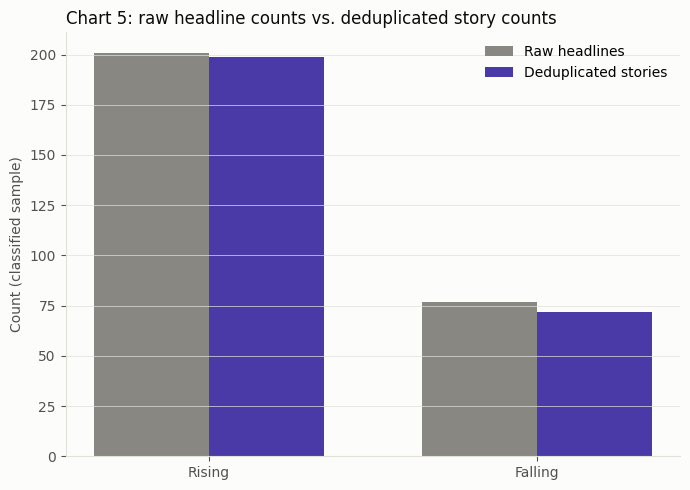

In [26]:
# Chart 5: raw vs deduplicated counts
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, raw_totals.values, width, label='Raw headlines', color=MUTED)
ax.bar(x + width/2, dedup_totals.values, width, label='Deduplicated stories', color=C4)
ax.set_xticks(x)
ax.set_xticklabels(['Rising', 'Falling'])
ax.set_ylabel('Count (classified sample)')
ax.set_title('Chart 5: raw headline counts vs. deduplicated story counts', color=INK, loc='left')
ax.legend(frameon=False)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

## Section 10 — Interpretation

Three possible findings were on the table going in:

1. **Coverage accurately follows the direction of rent changes.**
2. **Falling rents receive greater attention** per quarter, or per
   percentage point of change, than rising rents do.
3. **Headlines frequently announce a decline without explaining** how
   little of the previous run-up has actually reversed.

The evidence in this notebook is consistent with a version of **all three
holding at once, to different degrees** — which is itself informative.

In [27]:
print('(1) DOES COVERAGE TRACK DIRECTION?')
print(f'  Headline framing signal correlates with the real QoQ change: r={r_dir:+.2f}, p={p_dir:.2g}.')
print(f'  Falling-headline share rose from {share_before:.0%} before the 2023Q4 peak to {share_after:.0%} after it.')
print('  -> Yes, broadly: coverage does track the direction of the real trend, both in the overall')
print('     correlation and in the sharp before/after-peak shift.')
print()
print('(2) DOES FALLING GET MORE ATTENTION PER QUARTER / PER POINT OF MAGNITUDE?')
print(f'  Falling headlines per falling-rent quarter: {headlines_per_falling_qtr:.1f} vs. '
      f'{headlines_per_rising_qtr:.1f} for rising quarters.')
print(f'  Falling headlines per point of magnitude: {per_point_falling:.2f} vs. {per_point_rising:.2f} '
      f'for rising ({per_point_falling/per_point_rising:.1f}x).')
print('  -> Modestly yes: falling rents draw somewhat more coverage per unit of quarterly change')
print('     than rising rents do, though the gap is not large by either measure.')
print()
print('(3) DO FALLING HEADLINES EXPLAIN HOW LITTLE HAS REVERSED?')
print(f'  Only {n_core}/{n_tot} ({n_core/n_tot:.1%}) of falling-rent headlines communicate that the')
print('  decline is small, or that rents remain high, or that rents remain well above an earlier')
print(f'  benchmark. {n_tot - n_any}/{n_tot} ({(n_tot-n_any)/n_tot:.1%}) carry no such context at all.')
print('  -> Yes, clearly: the large majority of falling-rent headlines report the reversal without')
print('     situating it against the much larger run-up that preceded it.')

(1) DOES COVERAGE TRACK DIRECTION?
  Headline framing signal correlates with the real QoQ change: r=-0.65, p=0.00017.
  Falling-headline share rose from 13% before the 2023Q4 peak to 50% after it.
  -> Yes, broadly: coverage does track the direction of the real trend, both in the overall
     correlation and in the sharp before/after-peak shift.

(2) DOES FALLING GET MORE ATTENTION PER QUARTER / PER POINT OF MAGNITUDE?
  Falling headlines per falling-rent quarter: 5.4 vs. 8.1 for rising quarters.
  Falling headlines per point of magnitude: 4.27 vs. 3.19 for rising (1.3x).
  -> Modestly yes: falling rents draw somewhat more coverage per unit of quarterly change
     than rising rents do, though the gap is not large by either measure.

(3) DO FALLING HEADLINES EXPLAIN HOW LITTLE HAS REVERSED?
  Only 10/77 (13.0%) of falling-rent headlines communicate that the
  decline is small, or that rents remain high, or that rents remain well above an earlier
  benchmark. 60/77 (77.9%) carry no such

**The preferred interpretation, on this evidence:**

> News coverage broadly tracks the direction of rents, but the recent
> reversal may receive more attention than its limited magnitude alone would
> suggest. Headlines can therefore create a stronger impression of
> rental-market relief when they report falling rents without also
> communicating the historically high level from which rents are falling.

A reversal after years of increases is inherently newsworthy — "rents keep
rising" for the fifth year running is a much weaker story than "rents finally
fall." That a genuine change in direction draws disproportionate attention,
on its own, does not establish inaccurate or biased reporting: it's a
description of what makes news, not a verdict on it. What Section 8 adds is
narrower and more specific — most falling-rent headlines in this sample
don't tell the reader how the fall compares to the run-up, which is a
separate, addressable gap in contextualization rather than a claim about
motive or accuracy.

## Section 11 — Limitations

- **Sample completeness.** `rent_rents.csv` depends on whatever search query
  and news-index coverage was used to build it; outlets, sections, or
  phrasings outside that query are invisible here, and there's no way to
  audit its recall from inside this notebook.
- **Search-query design.** Restricting to headlines containing "rent"/"rents"
  necessarily misses stories about rent trends that avoid those words in the
  headline (a paraphrase, a number-first framing, etc.).
- **Outlet representation.** The corpus is dominated by a handful of large
  chains (Metroland/Village Media-style local papers, CTV, the Star); a
  different outlet mix could shift the balance shown in Section 7.
- **Syndicated content.** Section 4's near-duplicate clustering is a
  word-overlap-plus-date-window heuristic, not a true wire-service match (no
  byline data available) — it will miss more heavily rewritten republications
  and could over-merge unrelated same-day stories that happen to share
  common words.
- **Classification error.** Semantic classification and manual validation
  found ~98% agreement on the reviewed subset (Section 3), but that subset
  was itself a sample (196 of 965) — some residual error is expected outside
  it, and the classification schema itself required judgment calls documented
  inline (e.g., individual landlord-tenant disputes over a single rent
  increase were kept as `rising`/`falling` rather than filtered out, to keep
  treatment symmetric between the two directions).
- **Local-match rate.** Section 7's headline-vs.-local-series agreement was
  only 65% — lower than might be expected, likely because many local
  headlines cite a different rent-data source (Rentals.ca, Zumper, local
  board of trade surveys) than this repo's StatCan-derived CMA series, and
  because city-level quarterly asking-rent figures are noisier than the
  national aggregate.
- **Headline vs. article framing.** Everything here codes the headline only.
  A headline reporting a "bare" decline may still be followed by an article
  body that explains the run-up in paragraph three — this notebook cannot
  distinguish that from an article that never mentions it at all. Coding a
  sample of subheadings or opening paragraphs would be the natural next step
  to check whether Section 8's finding holds at the article level, not just
  the headline level.
- **No universal benchmark for "proportionate" coverage.** Section 6's
  headlines-per-quarter and headlines-per-percentage-point figures are
  descriptive benchmarks, not evidence of a violated norm — there is no
  agreed-upon standard for how much coverage a given rent change "should"
  receive, and newsworthiness reasonably depends on more than magnitude alone
  (novelty, reversal-after-a-trend, audience relevance, competing news, etc.).